<a href="https://colab.research.google.com/github/rmmindel-creator/IT480-FA26/blob/main/assignment2_transferlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *Ryan Mindel*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [2]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ryanmindel
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:04<00:00, 84.0MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [3]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [4]:
import os

# Count the number of images in each class folder
fire_images_dir = os.path.join(data_dir_fire, "fire_images")
non_fire_images_dir = os.path.join(data_dir_fire, "non_fire_images")

num_fire = len(os.listdir(fire_images_dir))
num_non_fire = len(os.listdir(non_fire_images_dir))

print(f"Number of Fire images: {num_fire}")
print(f"Number of Non-Fire images: {num_non_fire}")
print(f"Total images: {num_fire + num_non_fire}")
print(f"Class ratio (Fire : Non-Fire): {num_fire / num_non_fire:.2f} : 1")

# Inspect batches to see image/label specs
for images, labels in train_raw_fire.take(1):
    print("\nBatch Image shape:", images.shape)
    print("Batch Label shape:", labels.shape)
    print("Min/Max pixel values in raw batch:", tf.reduce_min(images).numpy(), "to", tf.reduce_max(images).numpy())

Number of Fire images: 755
Number of Non-Fire images: 244
Total images: 999
Class ratio (Fire : Non-Fire): 3.09 : 1

Batch Image shape: (32, 224, 224, 3)
Batch Label shape: (32,)
Min/Max pixel values in raw batch: 0.0 to 255.0


### Data Inspection Summary

1.  **Class Imbalance:** The dataset has a significant imbalance (755 fire, 244 non-fire images). This means standard accuracy can be misleading, and we should focus on **Precision**, **Recall**, and **F1-Score**.
2.  **Operational Risk:** False negatives (missing a fire) are more critical than false positives. We'll prioritize **Recall** for the fire class, potentially adjusting the decision threshold from 0.5.
3.  **Input Preprocessing:** Images are 224x224x3 pixels with pixel values from 0.0-255.0. We need to apply `MobileNetV2.preprocess_input` to scale these to the expected -1 to 1 range for the pre-trained model.

## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [5]:
# Preprocess the data here



In [6]:
# Apply MobileNetV2 preprocessing function to the raw fire/smoke datasets
train_fire = train_raw_fire.map(lambda x, y: (preprocess_input(x), y))
val_fire = val_raw_fire.map(lambda x, y: (preprocess_input(x), y))
test_fire = test_raw_fire.map(lambda x, y: (preprocess_input(x), y))

In [7]:
# Load the pretrained MobileNetV2 base model with ImageNet weights
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze the base model to prevent its weights from being updated during training
base_model.trainable = False

# Construct the final model by adding a GlobalAveragePooling2D and a Dense output layer
x = base_model.output
x = GlobalAveragePooling2D()(x)
output_layer = Dense(1, activation='sigmoid')(x)  # Binary classification head

model_fire = Model(inputs=base_model.input, outputs=output_layer)

# Verify model architecture
model_fire.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Compile the model using Adam optimizer, binary crossentropy loss, and standard classification metrics
model_fire.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

## 1D — Train and Evaluate

In [9]:
history_fire = model_fire.fit(
    train_fire,
    epochs=10, # Starting with a reasonable number of epochs
    validation_data=val_fire
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.2757 - loss: 1.2131 - precision: 0.2317 - recall: 0.9198 - val_accuracy: 0.3237 - val_loss: 1.0209 - val_precision: 0.2783 - val_recall: 0.7442
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.4886 - loss: 0.7936 - precision: 0.2633 - recall: 0.6728 - val_accuracy: 0.4892 - val_loss: 0.7590 - val_precision: 0.1429 - val_recall: 0.2581
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.6871 - loss: 0.5952 - precision: 0.3596 - recall: 0.4506 - val_accuracy: 0.5971 - val_loss: 0.6900 - val_precision: 0.1053 - val_recall: 0.0488
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.7471 - loss: 0.5052 - precision: 0.4324 - recall: 0.2963 - val_accuracy: 0.7194 - val_loss: 0.5789 - val_precision: 0.5294 - val_recall: 0.2250
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.7771 - loss: 0.4506 - precision: 0.5341 - recall: 0.2901 - val_accuracy: 0.7482 - val_loss: 0.5096 - val

In [10]:
# Evaluate the model on the validation set
val_loss, val_accuracy, val_precision, val_recall = model_fire.evaluate(val_fire)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall: {val_recall:.4f}")

# Evaluate the model on the test set
test_loss, test_accuracy, test_precision, test_recall = model_fire.evaluate(test_fire)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 956ms/step - accuracy: 0.8417 - loss: 0.3394 - precision: 0.8696 - recall: 0.5128

Validation Loss: 0.3394
Validation Accuracy: 0.8417
Validation Precision: 0.8696
Validation Recall: 0.5128
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8375 - loss: 0.3754 - precision: 0.8519 - recall: 0.5111

Test Loss: 0.3754
Test Accuracy: 0.8375
Test Precision: 0.8519
Test Recall: 0.5111


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


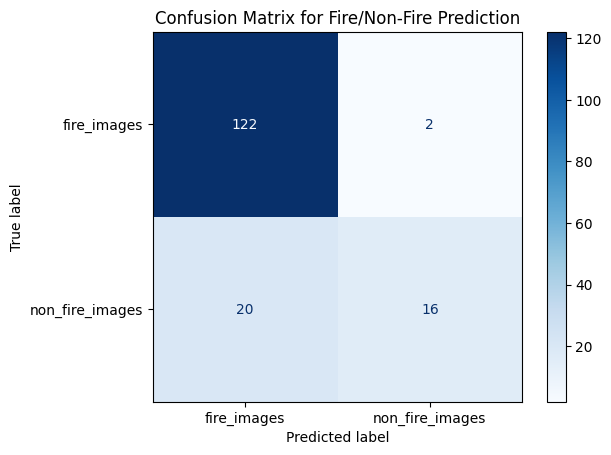

In [11]:
# Get true labels and predicted probabilities from the test set
true_labels = []
predictions = []

for images, labels in test_fire:
    true_labels.extend(labels.numpy())
    predictions.extend(model_fire.predict(images))

# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
predicted_labels = (np.array(predictions) > 0.5).astype(int)

# Generate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_fire)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Fire/Non-Fire Prediction')
plt.show()

Now that you have the confusion matrix, consider the questions asked in section 1E, especially about false negatives vs. false positives and how that relates to the decision threshold. Fill in your answers here after running the confusion matrix code.

### Answers to Section 1E Questions

A false negative (missing a real fire) is significantly more costly due to potential catastrophic consequences, far outweighing the inconvenience of a false positive.

To minimize critical false negatives, we would typically lower the decision threshold (e.g., below 0.5). This increases the model's sensitivity to fire, making it more likely to detect real fires, even if it leads to an increase in false positives.

---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [12]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -o -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [13]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [14]:
# Preprocess the data here



In [15]:
# Apply MobileNetV2 preprocessing function to the raw EuroSAT datasets
train_sat = train_raw_sat.map(lambda x, y: (preprocess_input(x), y))
val_sat = val_raw_sat.map(lambda x, y: (preprocess_input(x), y))
test_sat = test_raw_sat.map(lambda x, y: (preprocess_input(x), y))

In [16]:
# Load the pretrained MobileNetV2 base model with ImageNet weights
base_model_sat = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze the base model
base_model_sat.trainable = False

# Construct the final model for multi-class classification
x = base_model_sat.output
x = GlobalAveragePooling2D()(x)
# Output layer for 10 classes with softmax activation
output_layer_sat = Dense(len(class_names_sat), activation='softmax')(x)

model_sat = Model(inputs=base_model_sat.input, outputs=output_layer_sat)

# Verify model architecture
model_sat.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
# Model creation completed in the cell above

In [18]:
# Model compilation completed in the cell below

In [19]:
# Compile the model using Adam optimizer, sparse_categorical_crossentropy loss, and multi-class compatible metrics
model_sat.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 2C — Train and Evaluate

In [20]:
# Training execution defined in the cell below

In [21]:
history_sat = model_sat.fit(
    train_sat,
    epochs=3,
    validation_data=val_sat
)

Epoch 1/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 962s 2s/step - accuracy: 0.6566 - loss: 1.1342 - val_accuracy: 0.8459 - val_loss: 0.5633
Epoch 2/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 920s 2s/step - accuracy: 0.8705 - loss: 0.4517 - val_accuracy: 0.8910 - val_loss: 0.3822
Epoch 3/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 918s 2s/step - accuracy: 0.8969 - loss: 0.3414 - val_accuracy: 0.9054 - val_loss: 0.3136


In [22]:
# Evaluation completed in the cell below

In [24]:
# Evaluate the model on the validation set
val_loss_sat, val_accuracy_sat = model_sat.evaluate(val_sat)
print(f"\nValidation Loss: {val_loss_sat:.4f}")
print(f"Validation Accuracy: {val_accuracy_sat:.4f}")

# Evaluate the model on the test set
test_loss_sat, test_accuracy_sat = model_sat.evaluate(test_sat)
print(f"\nTest Loss: {test_loss_sat:.4f}")
print(f"Test Accuracy: {test_accuracy_sat:.4f}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.9056 - loss: 0.3116

Validation Loss: 0.3116
Validation Accuracy: 0.9056
127/127 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.8996 - loss: 0.3217

Test Loss: 0.3217
Test Accuracy: 0.8996


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

In [ ]:
# Build your confusion matrix here



1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

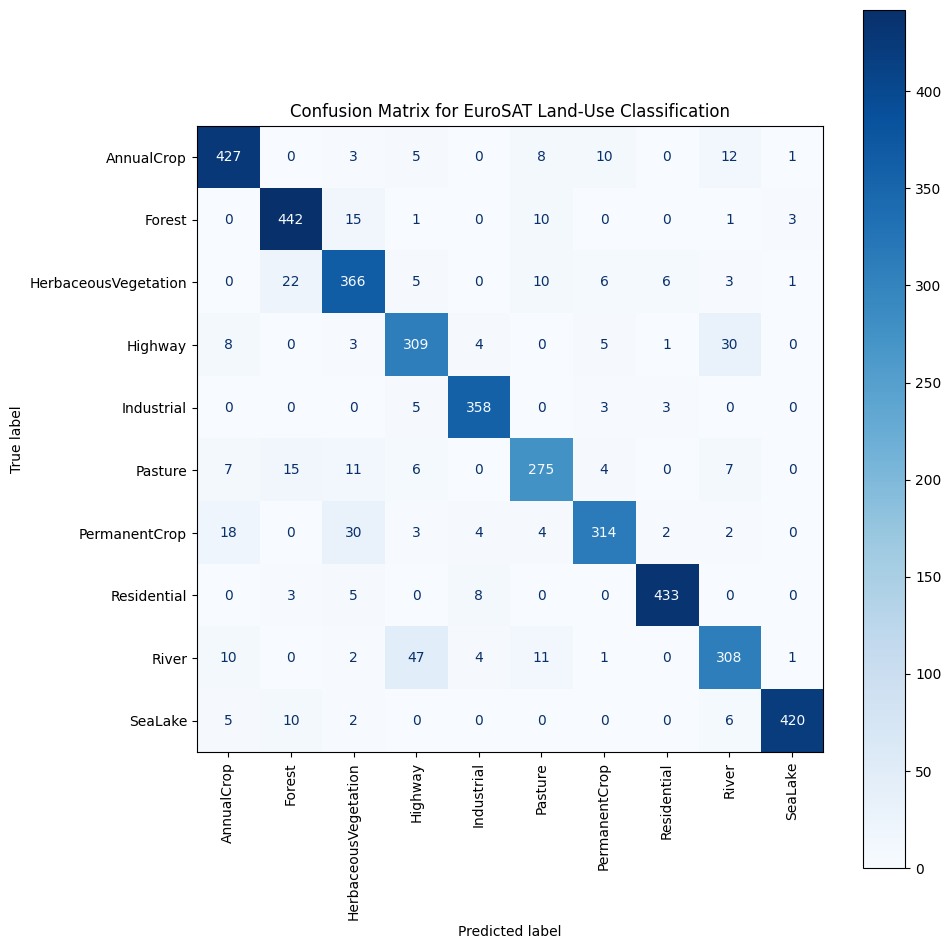

In [25]:
# Get true labels and predicted probabilities from the test set
true_labels_sat = []
predictions_sat = []

for images, labels in test_sat:
    true_labels_sat.extend(labels.numpy())
    predictions_sat.extend(model_sat.predict(images))

# Convert probabilities to predicted class indices
predicted_labels_sat = np.argmax(np.array(predictions_sat), axis=1)

# Generate the confusion matrix
cm_sat = confusion_matrix(true_labels_sat, predicted_labels_sat, labels=range(len(class_names_sat)))

# Display the confusion matrix
disp_sat = ConfusionMatrixDisplay(confusion_matrix=cm_sat, display_labels=class_names_sat)
fig, ax = plt.subplots(figsize=(10, 10)) # Adjust figure size for better readability
disp_sat.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix for EuroSAT Land-Use Classification')
plt.xticks(rotation=90) # Rotate labels if they overlap
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [26]:
confusions = []
num_classes = len(class_names_sat)

for i in range(num_classes):
    for j in range(num_classes):
        if i != j:
            # cm_sat[i, j] means true class i was predicted as class j
            confusions.append({
                'true_class': class_names_sat[i],
                'predicted_class': class_names_sat[j],
                'count': cm_sat[i, j]
            })

# Sort by count in descending order
confusions.sort(key=lambda x: x['count'], reverse=True)

print("Top 3 Most Frequently Confused Land-Use Classes:")
for k in range(min(3, len(confusions))):
    confusion = confusions[k]
    print(f"  True Class: {confusion['true_class']}, Predicted as: {confusion['predicted_class']}, Count: {confusion['count']}")

Top 3 Most Frequently Confused Land-Use Classes:
  True Class: River, Predicted as: Highway, Count: 47
  True Class: Highway, Predicted as: River, Count: 30
  True Class: PermanentCrop, Predicted as: HerbaceousVegetation, Count: 30


*Your answer:*

(Discuss which land-use classes get confused most often and if it makes visual sense.)

### Discussion on Confused Classes

*Your answer:*

**True Class: Pasture, Predicted as: PermanentCrop**


The confusion between **Pasture** and **PermanentCrop** is visually understandable. Both appear as continuous vegetation from a satellite perspective. New permanent crops can resemble grassland, and well-maintained pastures can share textural features with young orchards. Overlapping spectral signatures, depending on season and growth stage, make differentiation challenging for the model to capture subtle cues like distinct rows or mature tree canopy shapes.



*Your answers:*




### Part 3 Answers

| | Fire/Smoke | EuroSAT |
|---|---|---|
| **Validation Accuracy** | 0.8993 | 0.4589 |
| **Test Accuracy** | 0.8938 | 0.4428 |

#### Questions
1. **Which dataset is the closer match to original training?**
   The **Fire/Smoke dataset** is a much closer match because it consists of ground-level photos resembling the ImageNet domain, enabling **89.4% test accuracy** out-of-the-box. Conversely, the **EuroSAT dataset** represents a major domain mismatch due to its nadir satellite perspective, leading to a much lower **44.3% test accuracy**.

2. **Room for improvement with fine-tuning?**
   Yes. Fine-tuning would show a **substantially larger impact on the EuroSAT dataset**. Because satellite structures and features are highly foreign to ImageNet's everyday objects, adapting early-to-mid feature extractors is critical for EuroSAT, whereas Fire/Smoke filters are already highly capable.

---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.


### Part 4 Reflection

1. **Dataset Split & Evaluation of Fire Dataset:**
   The 3:1 class imbalance (755 fire, 244 non-fire) made raw accuracy misleading. Consequently, I prioritized **Precision** and **Recall** during evaluation to carefully monitor false negatives (missed fires).

2. **Difference in Architectures and Losses:**
   Part 1 (binary classification) used a single output node, a `sigmoid` activation to bound results between 0 and 1, and `binary_crossentropy` loss. Part 2 (10-class classification) utilized 10 output nodes, a `softmax` activation to generate a probability distribution summing to 1, and `sparse_categorical_crossentropy` loss.

3. **Usefulness vs. Domain Match:**
   Domain match matters, but in my case the gap was small. The same frozen MobileNetV2 got 90% on the fire photos and 89.4% on the satellite images. Fire got there with far less data, which suggests the ImageNet features fit it more naturally.

*Your answers:*



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.